# Opiskelijakohortin opintojen keskeyttämisajan elinaikaanalyysi

## Tiivistelmä

**Tilanne.** Nelivuotisen korkeakoulun institutionaalisen tutkimuksen yksikkö haluaa ymmärtää, *milloin* opiskelijat lähtevät, ei vain *lähtevätkö* he. Ensikertalaisten kohorttia seurataan lukukausi lukukaudelta opintojen aloituksesta lähtien; osa valmistuu, osa keskeyttää, ja muutama on yhä kirjoilla, kun havainnointi-ikkuna sulkeutuu. Koska yhä kirjoilla olevien opiskelijoiden lopputulos on tuntematon (oikealta sensuroitu) ja koska valmistuminen poistaa opiskelijan riskijoukosta ilman että kyseessä on keskeyttäminen, tavanomainen läpäisy/hylkäys-regressio hukkaa ajoitustiedon ja vinouttaa jokaisen arvion, joka sivuuttaa sensuroinnin. Oikea työkalu on **tapahtuma-aika- eli elinaikaanalyysi**, jossa kiinnostuksen kohteena oleva tapahtuma on **keskeyttäminen** ja aikaa mitataan suoritettuina lukukausina.

**Liiketoimintakysymys.** Erotteleeko opiskelijan **ensimmäisen lukukauden akateeminen asema** (varhaisen varoituksen merkki) kohortin keskeyttämisajan kehityskulut, ja mitkä opiskelijoiden ominaisuudet ajavat keskeyttämisriskiä vakioinnin jälkeen? Vastaukset syötetään varhaisen varoituksen järjestelmään: opiskelijat, joiden arvioitu keskeyttämisriski on korkea, tulisi ohjata neuvontaan ensimmäisillä lukukausillaan, jolloin puuttuminen on halvinta ja tehokkainta.

**Lähestymistapa.** Simuloimme 100 opiskelijan kohortin suoraan koodissa (ei ulkoista dataa) ja käymme sitten läpi tavanomaisen elinaikaanalyysin työnkulun:

1. **PROC MEANS** profiloi selittävät muuttujat kolmen havaitun lopputuloksen (Valmistunut / Keskeyttänyt / yhä Kirjoilla) välillä varmistaen, että simuloitu signaali käyttäytyy järkevästi.
2. **PROC FREQ** ristiintaulukoi ensimmäisen lukukauden akateemisen aseman lopputulosta vasten khiin neliö -riippumattomuustestillä.
3. **PROC UNIVARIATE** raportoi keskeyttämisajan robustit persentiilit aseman mukaan.
4. **PROC LIFETEST** estimoi Kaplan-Meier-keskeyttämiskäyrät aseman mukaan ositettuna ja suorittaa **log-rank**- ja **Wilcoxon**-yhtäsuuruustestit.
5. **PROC PHREG** sovittaa monimuuttujaisen **Coxin suhteellisten riskien** mallin keskeyttämisriskille käyttäen viitekoodattua `CLASS`-vaikutusta, Efronin sidosten käsittelyä ja riskirajojen luottamusvälejä.

**Mitä data osoittaa.** 100 simuloidusta opiskelijasta **49 keskeytti, 49 valmistui ja 2 pysyi kirjoilla** 12 lukukauden katkaisurajalla. Opiskelijat, jotka saivat **akateemisen varoituksen** ensimmäisellä lukukaudellaan (ensimmäisen lukukauden keskiarvo alle 2,5), keskeyttävät paljon nopeammin kuin hyvässä asemassa olevat opiskelijat: keskeyttämisajan mediaani **3,8 lukukautta vs. 8,7 lukukautta**, erottelu jonka log-rank-testi vahvistaa (khiin neliö = 10,73, *p* = 0,0011). Coxin malli tunnistaa ensimmäisen lukukauden keskiarvon (riskisuhde 0,21 keskiarvopistettä kohti, *p* < 0,0001), lukion keskiarvon (HR 0,45, *p* = 0,027) ja ensimmäisen polven opiskelijan aseman (HR 2,03, *p* = 0,031) merkitseviksi vakioiduiksi keskeyttämisen ajureiksi, kun taas Pell-apurahan asema ei ole merkitsevä, kun keskiarvo on vakioitu (HR 0,95, *p* = 0,85).

> *Kaikki luvut ovat havainnollistavia ja tuotettu synteettisestä datasta; ne eivät ole todellisia opiskelijatietoja. Tämä ympäristö toimii ilman lisenssiä, joten kohortin kooksi on asetettu 100 opiskelijaa.*

## Datalähteet

Kaikki data on **synteettistä**, tuotettu suoraan ensimmäisessä DATA-askeleessa käyttäen `CALL STREAMINIT(20260611)` -kutsua ja `RAND`-funktiota. Ei ulkoisia tiedostoja tai verkkoyhteyttä. Yksi rivi per simuloitu opiskelija.

**Aineisto `ilmoittautumiset`** (100 riviä, yksi rivi per opiskelija)

| Muuttuja | Tyyppi | Kuvaus | Generoiva jakauma |
|----------|------|-------------|--------------------------|
| `opiskelija_id` | Num | Yksilöivä opiskelija-avain | jono 1–100 |
| `ensimmainen_polvi` / `ensimmainen_polvi_nimike` | Num / Char | Ensimmäisen polven merkki (0/1) ja nimike | Bernoulli, ~42 % |
| `pell` | Num | Pell-apurahan (taloudellisen tarpeen) merkki (0/1) | Bernoulli, ~42 % |
| `ohjelma` | Char | STEM / BUS / HUM | kategorinen (~42 % / 32 % / 26 %) |
| `lukio_ka` | Num | Lukion keskiarvo (1,8–4,0) | Normal(3.00, 0.42), rajattu |
| `lk1_ka` | Num | Ensimmäisen lukukauden korkeakoulukeskiarvo (0–4,0) | f(hs_gpa, program) + Normal-kohina |
| `asema` | Char | Ensimmäisen lukukauden akateeminen asema | `lk1_ka < 2.5` → Akateeminen varoitus, muuten Hyvä asema |
| `aika_lukukaudet` | Num | Kirjoilla suoritetut lukukaudet tapahtumaan tai sensurointiin asti | kilpailevat Weibull-vedot; katkaistu arvoon 12 |
| `keskeyttanyt` | Num | Keskeyttämistapahtuman ilmaisin (1 = keskeytti, 0 = sensuroitu) | johdettu |
| `lopputulos` | Char | Valmistunut / Keskeyttänyt / Kirjoilla | johdettu kilpailevista vedoista |

Latentti lineaarinen ennustaja logaritmisella asteikolla yhdistää jokaisen opiskelijan **keskeyttämisnopeuden** ensimmäisen lukukauden keskiarvoon, lukion keskiarvoon, ensimmäisen polven asemaan ja taloudelliseen tarpeeseen, joten selittävät muuttujat kantavat aitoa mutta kohinaista signaalia. Keskeyttäminen ja valmistuminen vedetään **kilpailevina** latentteina aikoina (Weibull); kumpi tahansa tapahtuu ensin 12 lukukauden ikkunan sisällä, siitä tulee havaittu lopputulos, ja opiskelijat, jotka saavuttavat lukukauden 12 ilman kumpaakaan, sensuroidaan oikealta. Elinaikamalleissa **tapahtuma on keskeyttäminen** (`keskeyttanyt = 1`); valmistuminen ja jatkuva kirjoilla oleminen käsitellään molemmat sensurointina (`keskeyttanyt = 0`).

## 1. Simuloi opiskelijakohortti

Ensimmäinen solu rakentaa synteettisen 100 opiskelijan kohortin. Latentti lineaarinen ennustaja logaritmisella asteikolla sitoo jokaisen opiskelijan keskeyttämisnopeuden ensimmäisen lukukauden keskiarvoon, lukion keskiarvoon, ensimmäisen polven asemaan ja Pell-asemaan. Keskeyttäminen ja valmistuminen tuotetaan **kilpailevina** latentteina aikoina (Weibull-vedot); kumpi tahansa tapahtuu ensin 12 lukukauden havainnointi-ikkunan sisällä, siitä tulee havaittu lopputulos, ja opiskelijat, jotka saavuttavat lukukauden 12 keskeyttämättä tai valmistumatta, sensuroidaan oikealta. Ensimmäisen lukukauden keskiarvo alle 2,5 merkitsee opiskelijan **akateemiseen varoitukseen** — varhaisen varoituksen signaali, jota testaamme elinaika-askeleessa. Satunnaisvedot käyttävät `CALL STREAMINIT` -kutsua toistettavuuden vuoksi ja `RAND`-funktiota Uniform-, Normal- ja Weibull-jakaumien yli. Kovat alarajat ja rajaukset pitävät jokaisen arvon uskottavana (keskiarvot välillä 0–4,0).

In [1]:
TIEDOT ilmoittautumiset;
    CALL streaminit(20260611);
    PITUUS asema $24 ensimmainen_polvi_nimike $24 ohjelma $4 lopputulos $12;
    NIMIKE
        opiskelija_id            = "Opiskelijan tunnus"
        ensimmainen_polvi        = "Ensimmäisen polven merkki"
        ensimmainen_polvi_nimike = "Ensimmäisen polven asema"
        pell                     = "Pell-apuraha"
        ohjelma                  = "Opinto-ohjelma"
        lukio_ka                 = "Lukion keskiarvo"
        lk1_ka                   = "Ensimmäisen lukukauden keskiarvo"
        asema                    = "Akateeminen asema"
        aika_lukukaudet          = "Aika (lukukausina)"
        keskeyttanyt             = "Keskeyttämistapahtuma"
        lopputulos               = "Lopputulos";
    TEE opiskelija_id = 1 ASTI 100;
        /* Ensimmäisen polven ja taloudellisen tarpeen merkit */
        ensimmainen_polvi = (rand("uniform") < 0.42);
        JOS ensimmainen_polvi NIIN ensimmainen_polvi_nimike = "Ensimmäisen polven";
        MUUTEN                     ensimmainen_polvi_nimike = "Jatkava polvi";
        pell = (rand("uniform") < 0.42);

        /* Opinto-ohjelma */
        v = rand("uniform");
        JOS      v < 0.42 NIIN ohjelma = "STEM";
        MUUTEN JOS v < 0.74 NIIN ohjelma = "BUS";
        MUUTEN                  ohjelma = "HUM";

        /* Akateeminen valmius ja ensimmäisen lukukauden suoritus */
        lukio_ka = round(MIN(4.0, MAX(1.8, rand("normal", 3.00, 0.42))), 0.01);
        lk1_ka = round(MIN(4.0, MAX(0.0,
                     0.55*lukio_ka + 1.05 + 0.12*(ohjelma="STEM")
                     + rand("normal", 0, 0.42))), 0.01);

        /* Varhaisen varoituksen merkki: ensimmäisen lukukauden
           keskiarvo alle 2,5 = opintovaroitus */
        JOS lk1_ka < 2.5 NIIN asema = "Opintovaroitus";
        MUUTEN               asema = "Hyvä opintomenestys";

        /* Latentti keskeyttämisriski logaritmisella asteikolla: matalampi
           keskiarvo, ensimmäisen polven asema ja Pell-asema nostavat
           keskeyttämisnopeutta. */
        eta = -1.05
             - 1.45*(lk1_ka - 2.8)
             - 0.55*(lukio_ka - 3.0)
             + 1.05*ensimmainen_polvi
             + 0.45*pell;
        keskeytys_nopeus = EXP(eta);

        /* Kilpailevat latentit ajat (lukukausina): keskeyttaminen vs. valmistuminen */
        t_keskeytys = rand("weibull", 1.2, 7.0) / MAX(0.30, keskeytys_nopeus);
        t_valmistuminen = rand("weibull", 2.0, 7.5)
                 * EXP(-0.18*(lk1_ka - 2.8));

        /* 12 lukukauden hallinnollinen sensurointi-ikkuna */
        sensurointi_raja = 12;
        JOS t_keskeytys <= t_valmistuminen AND t_keskeytys <= sensurointi_raja NIIN TEE;
            lopputulos = "Keskeytti";  keskeyttanyt = 1; aika_lukukaudet = t_keskeytys;
        LOPPU;
        MUUTEN JOS t_valmistuminen < t_keskeytys AND t_valmistuminen <= sensurointi_raja NIIN TEE;
            lopputulos = "Valmistui"; keskeyttanyt = 0; aika_lukukaudet = t_valmistuminen;
        LOPPU;
        MUUTEN TEE;
            lopputulos = "Kirjoilla"; keskeyttanyt = 0; aika_lukukaudet = sensurointi_raja;
        LOPPU;
        aika_lukukaudet = round(aika_lukukaudet, 0.1);
        TULOSTE;
    LOPPU;
    SÄILYTÄ opiskelija_id ensimmainen_polvi ensimmainen_polvi_nimike pell ohjelma lukio_ka
         lk1_ka asema aika_lukukaudet keskeyttanyt lopputulos;
SUORITA;


NOTE: DATA ilmoittautumiset


NOTE: Wrote ilmoittautumiset (100 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds


## 2. Profiloi selittävät muuttujat havaitun lopputuloksen mukaan

Ennen mallinnusta varmistamme, että simuloidut selittävät muuttujat liikkuvat odotettuihin suuntiin. **PROC MEANS** raportoi kunkin numeerisen selittävän muuttujan lukumäärän, keskiarvon, hajonnan ja vaihteluvälin kolmen havaitun lopputuloksen sisällä.

Kohortti jakautuu **49 Valmistunut / 49 Keskeyttänyt / 2 yhä Kirjoilla**. Valmistuneilla on korkeampi ensimmäisen lukukauden keskiarvo (keskiarvo **2,94** vs. **2,54** keskeyttäneillä) ja korkeampi lukion keskiarvo (**3,10** vs. **2,90**) — juuri se akateemisen valmiuden gradientti, jota analyysi odottaa. Kaksi yhä kirjoilla olevaa opiskelijaa sijaitsevat täsmälleen 12 lukukauden sensurointikatolla muuttujassa `aika_lukukaudet` (keskiarvo 12,00, keskihajonta 0), oikea sensurointi jota poistuma-analyysin on kunnioitettava. Keskeyttäneiden joukossa tapahtuma saapuu aikaisin: keskiarvo **3,31 lukukautta**, vaihdellen välillä 0,1–8,9.

In [2]:
PROSEDUURI KESKIARVOT TIEDOT=ilmoittautumiset n mean std MIN MAX maxdec=2;
    LUOKKA lopputulos;
    MUUTTUJA lukio_ka lk1_ka aika_lukukaudet;
SUORITA;

                                                  The MEANS Procedure

                                     Analysis Variable : lukio_ka Lukion keskiarvo

        Lopputulos          N Obs           Mean        Std Dev        Minimum        Maximum
        -------------------------------------------------------------------------------------
        Keskeytti              49           2.90           0.45           2.01           3.89
        Kirjoilla               2           3.10           0.17           2.98           3.22
        Valmistui              49           3.10           0.46           1.97           4.00
        -------------------------------------------------------------------------------------

                              Analysis Variable : lk1_ka Ensimmäisen lukukauden keskiarvo

        Lopputulos          N Obs           Mean        Std Dev        Minimum        Maximum
        -------------------------------------------------------------------------------------
 


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 3. Seuraako varhaisen varoituksen merkki lopputulosta?

Varhaisen varoituksen järjestelmä merkitsee jokaisen opiskelijan, jonka ensimmäisen lukukauden keskiarvo jää alle 2,5, **akateemiseen varoitukseen**. **PROC FREQ** ristiintaulukoi tuon merkin havaittua lopputulosta vasten ja suorittaa khiin neliö -riippumattomuustestin. Vaimennamme rivi-, sarake- ja kokonaisprosentit (`NOROW NOCOL NOPERCENT`), jotta taulukko näyttää raa'at lukumäärät, ja lisäämme `asema`-muuttujan ja ensimmäisen polven aseman yksisuuntaiset frekvenssit kohortin koostumusta varten.

Ristiintaulukko on jyrkkä: **29** akateemiseen varoitukseen merkitystä opiskelijasta **21 keskeytti** ja vain 8 valmistui; **71** hyvässä asemassa olevasta **41 valmistui** ja 28 keskeytti. Riippuvuus on merkitsevä (khiin neliö = 9,21, df = 2, *p* = 0,0100; Cramérin V = 0,30). Huomaa **sen mukana tulostuva varoitus**: 100 opiskelijalla ja ohuella kahden valmistuneen "Kirjoilla"-sarakkeella kolmasosalla taulukon soluista on odotetut lukumäärät alle 5, joten khiin neliö -*p*-arvo on tässä hauras. Juuri tuo hauraus on syy siihen, että seuraavien osioiden elinaikatestit — jotka käyttävät täyttä ajoitustietoa 3×2-taulukon sijaan — ovat luotettavampi aseman vaikutuksen testi.

                                                   The FREQ Procedure

Table of Akateeminen asema by Lopputulos

Akateeminen asema    | Keskeytti | Kirjoilla | Valmistui |      Total
---------------------+-----------+-----------+-----------+-----------
Hyvä opintomenestys  |        28 |         2 |        41 |         71
---------------------+-----------+-----------+-----------+-----------
Opintovaroitus       |        21 |         0 |         8 |         29
---------------------+-----------+-----------+-----------+-----------
Total                |        49 |         2 |        49 |        100

Statistics for Table of Akateeminen asema by Lopputulos

Statistic                                DF  Value         Prob
--------------------------------------------------------------
Chi-Square                                2 9.2089       0.0100
Likelihood Ratio Chi-Square               2 9.8909       0.0071

Cramer's V                           0.3035
Contingency Coefficient              0.


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_asema_lopputulos.spec.json
NOTE: ODS plot written: freq_asema.spec.json
NOTE: ODS plot written: freq_ensimmainen_polvi_nimike.spec.json
NOTE: PROC FREQ statement used.


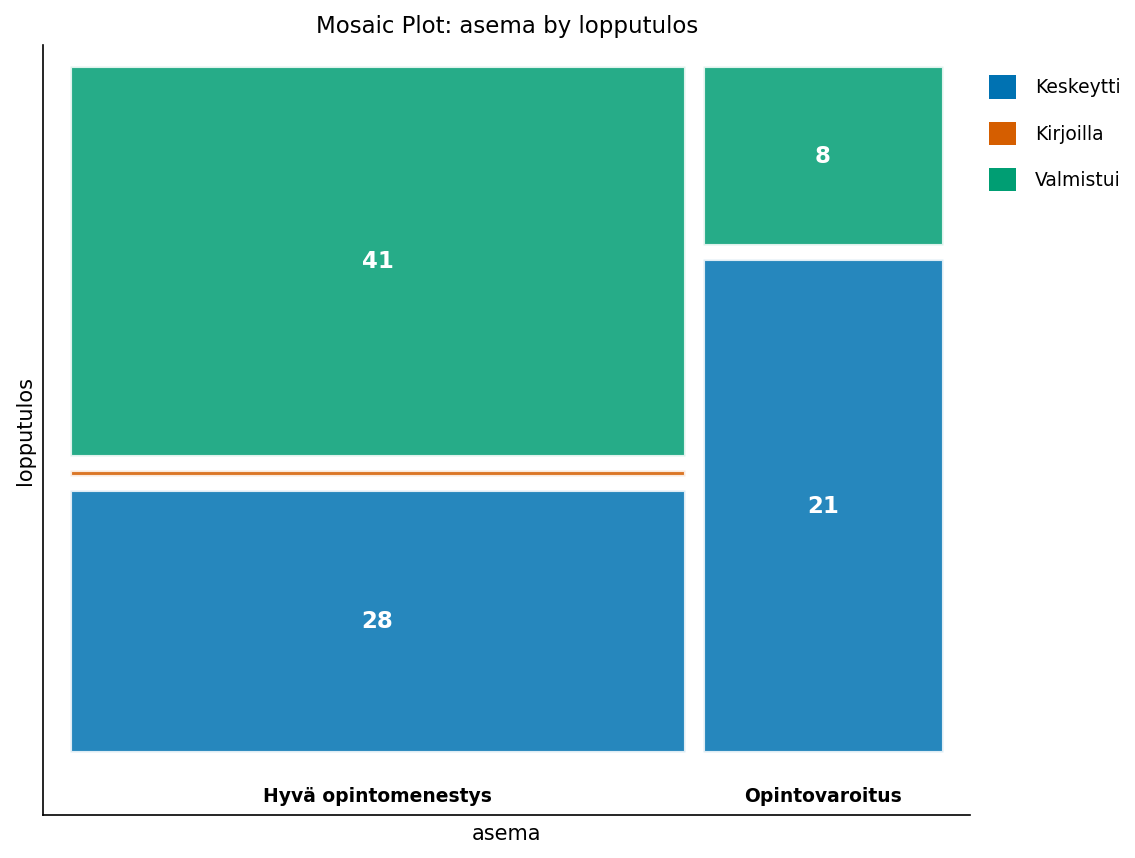

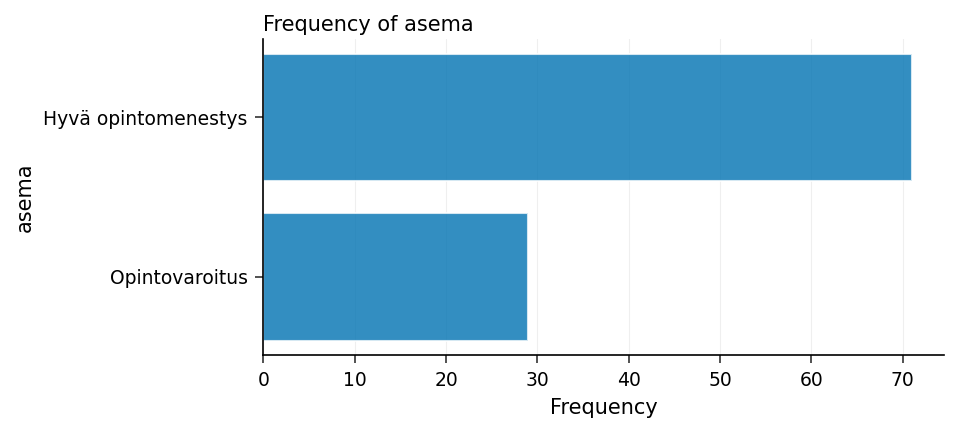

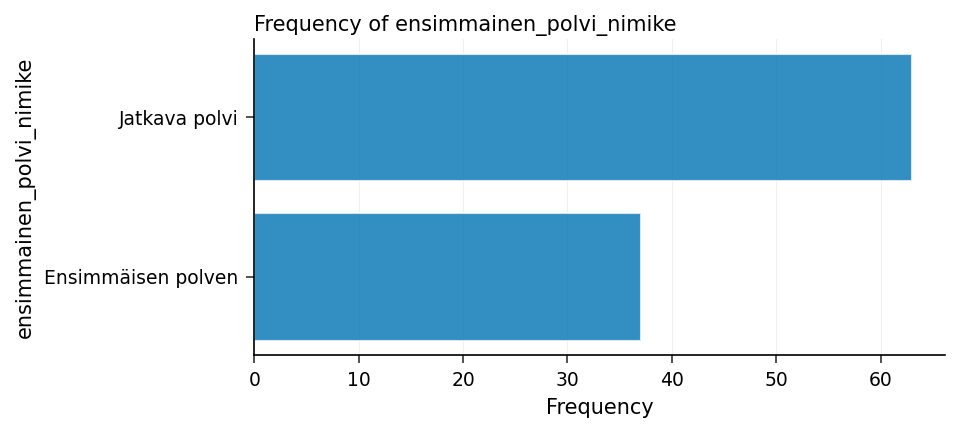

In [3]:
PROSEDUURI FREKVENSSIT TIEDOT=ilmoittautumiset;
    TABLES asema*lopputulos / chisq norow nocol nopercent;
    TABLES asema ensimmainen_polvi_nimike;
SUORITA;

## 4. Milloin keskeyttämiset tapahtuvat? Persentiilit aseman mukaan

Opiskelijoille, jotka todella keskeyttivät, *milloin* he lähtivät? **PROC UNIVARIATE** (rajattu arvoon `keskeyttanyt = 1`) raportoi keskeyttämisajan 10., 50. (mediaani) ja 90. persentiilin kunkin asemaryhmän sisällä, kirjoitettuna tulosaineistoon, jonka sitten tulostamme. Tämä kuvaa keskeyttämisajan hajonnan olettamatta jakaumaa.

Keskeyttäneiden mediaanikeskeyttäminen tapahtuu noin lukukauden **2,4** kohdalla (akateeminen varoitus) verrattuna arvoon **2,6** (hyvä asema) — läheiset, koska *ehdolla että keskeyttää*, molemmat ryhmät pyrkivät lähtemään aikaisin. Aseman vaikutus ei siis ole pääasiassa siitä, *milloin* keskeyttäminen tapahtuu, vaan siitä *kuinka moni* opiskelija keskeyttää ja kuinka nopeasti riskijoukko harvenee, mikä on juuri se, minkä seuraavan osion Kaplan-Meier-käyrät vangitsevat.

In [4]:
PROSEDUURI UNIVARIATE TIEDOT=ilmoittautumiset NOPRINT;
    MISSÄ keskeyttanyt = 1;
    LUOKKA asema;
    MUUTTUJA aika_lukukaudet;
    TULOSTE out=keskeytys_pers pctlpts=10 50 90 pctlpre=t_ p=;
SUORITA;

PROSEDUURI TULOSTA TIEDOT=keskeytys_pers noobs NIMIKE;
    OTSIKKO "Keskeyttämisajan persentiilit (lukukausina) akateemisen aseman mukaan";
SUORITA;
OTSIKKO;

                         Keskeyttämisajan persentiilit (lukukausina) akateemisen aseman mukaan                          

               ASEMA  T_10  T_50  T_90
Hyvä opintomenestys    0.4   2.6   8.7
Opintovaroitus         0.2   2.4   7.9




NOTE: PROC UNIVARIATE
NOTE: Output dataset keskeytys_pers has 2 observations and 4 variables.
NOTE: PROC PRINT data=keskeytys_pers

NOTE: PROC PRINT completed: 2 observations printed, 4 variables


## 5. Kaplan-Meier-keskeyttämiskäyrät akateemisen aseman mukaan

Nyt elinaikaanalyysin ydinaskel. **PROC LIFETEST** estimoi *keskeyttämisajan* epäparametrisen **Kaplan-Meier**-eloonjäämisfunktion käsitellen valmistumista ja jatkuvaa kirjoilla oloa sensurointina (`keskeyttanyt(0)` merkitsee sensuroidut havainnot). Ositus muuttujalla `asema` tuottaa yhden keskeyttämiskäyrän per ryhmä, ja `TEST=(LOGRANK WILCOXON)` suorittaa kaksi toisiaan täydentävää testiä sille, eroavatko nuo käyrät: **log-rank**-testi painottaa kaikkia tapahtuma-aikoja yhtäläisesti (herkkä myöhäisille eroille), kun taas **Wilcoxon**-testi ylipainottaa aikaisia tapahtuma-aikoja (herkkä varhaiselle poistumalle). `PLOTS=SURVIVAL` pyytää päällekkäin asetetun eloonjäämiskäyrägrafiikan.

Koko kohortissa on **49 keskeyttämistapahtumaa ja 51 sensuroitua** havaintoa. Käyrät erottuvat selvästi: akateemisessa varoituksessa olevat opiskelijat saavuttavat **eloonjäämismediaanin (keskeyttämisajan) 3,8 lukukautta**, kun taas hyvässä asemassa olevat opiskelijat kestävät yli kaksi kertaa kauemmin (**8,7 lukukautta**). Molemmat testit hylkäävät yhtäsuuruuden — **log-rank khiin neliö = 10,73, *p* = 0,0011; Wilcoxon khiin neliö = 7,66, *p* = 0,0056** — ja vertailukelpoiset tunnusluvut kertovat, että ero säilyy koko ilmoittautumisikkunan yli, ei vain varhaisena piikkinä. Kuvaaja tekee viestin välittömäksi: oranssi akateemisen varoituksen käyrä laskee jyrkästi neljän ensimmäisen lukukauden aikana, kun taas sininen hyvän aseman käyrä pysyy korkealla.

    The LIFETEST Procedure    

                             N
--------------------  --------
Total                      100
Event                       49
Censored                    51
Median Survival Time    3.8500

Stratum: Akateeminen asema = Hyvä opintomenestys

                             N
--------------------  --------
Total                       71
Event                       28
Censored                    43
Median Survival Time    8.7000

               Product-Limit Survival Estimates                

    Time  Survival  Std Error  Number at Risk  Number of Events
--------  --------  ---------  --------------  ----------------
  0.1000    0.9859     0.0140              71                 1
  0.2000    0.9718     0.0196              70                 1
  0.4000    0.9577     0.0239              69                 1
  0.5000    0.9437     0.0274              68                 1
  0.7000    0.9296     0.0304              67                 1
  0.8000    0.9155     0.0330  


NOTE: PROC LIFETEST data=ilmoittautumiset

NOTE: Using Python lifelines version 0.30.3
NOTE: ODS plot written: survival_strata.spec.json
NOTE: PROC LIFETEST completed.


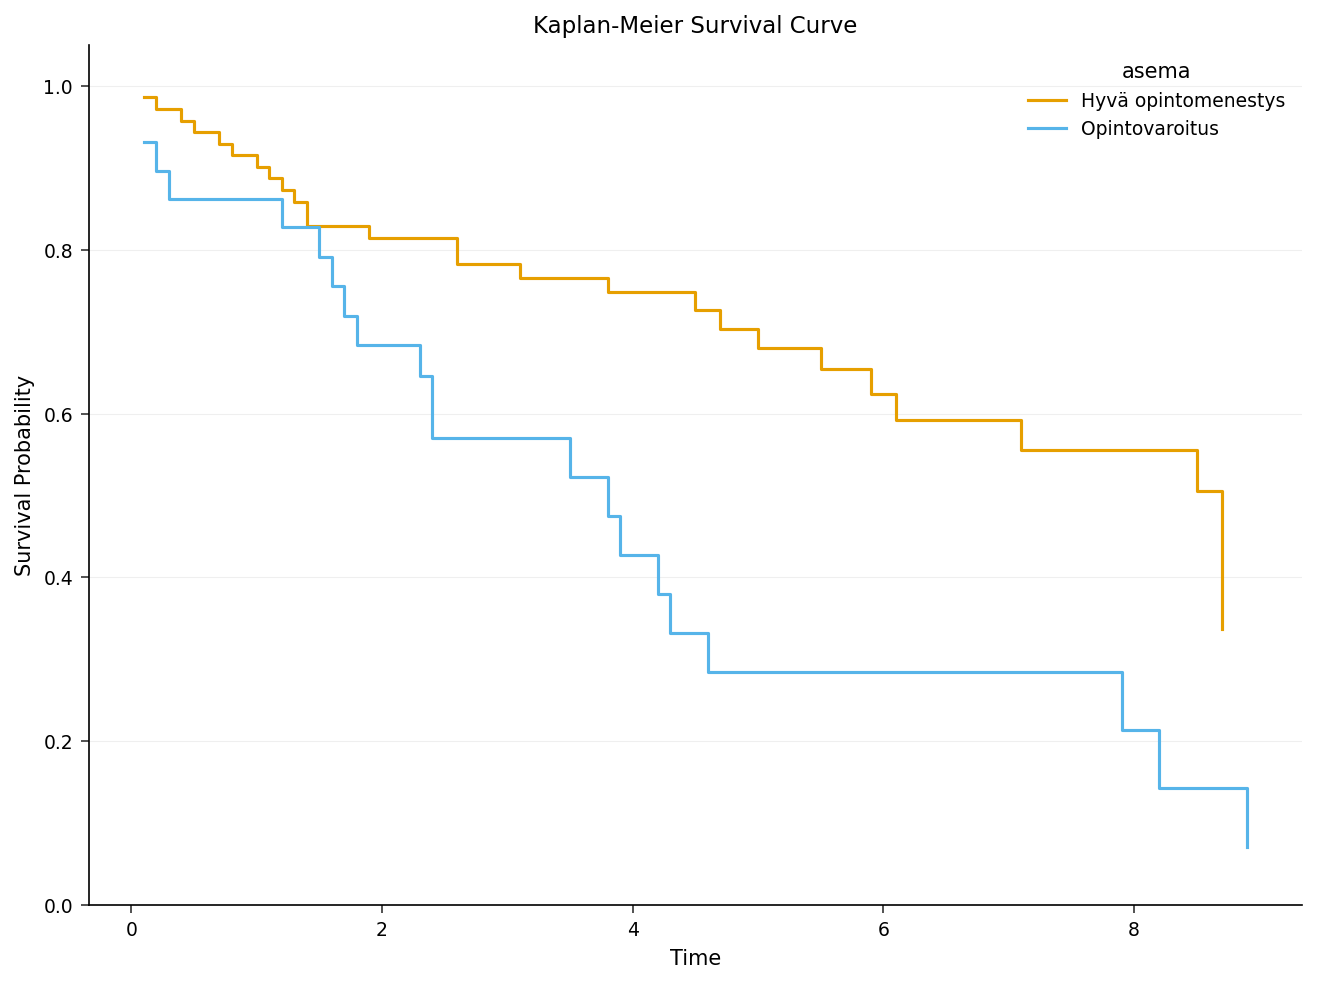

In [5]:
PROSEDUURI LIFETEST TIEDOT=ilmoittautumiset PLOTS=SURVIVAL METHOD=km;
    TIME aika_lukukaudet*keskeyttanyt(0);
    STRATA asema / TEST=(logrank WILCOXON);
SUORITA;

## 6. Monimuuttujainen Coxin suhteellisten riskien malli keskeyttämiselle

**PROC PHREG** sovittaa **Coxin suhteellisten riskien** mallin keskeyttämisriskille vakioiden selittävät muuttujat samanaikaisesti. Keskeiset pyynnöt:

- `keskeyttanyt(0)` tekee **keskeyttämisestä** tapahtuman ja kaikesta muusta sensuroidun.
- `CLASS ensimmainen_polvi_nimike (ref="Jatkava polvi") / param=ref` viitekoodaa ensimmäisen polven tekijän niin, että sen riskisuhde luetaan jatkuvan polven opiskelijoita vasten.
- `TIES=EFRON` on suositeltu sidosten käsittelyn approksimaatio, kun useita opiskelijoita lähtee samalla lukukaudella.
- `RL` lisää riskisuhteen (riskirajojen) luottamusvälit.
- `HAZARDRATIO`-lause raportoi ensimmäisen polven kontrastin viiteryhmää vasten.

Riskisuhde yli 1 tarkoittaa *nopeampaa* keskeyttämistä (korkeampi riski); alle 1 tarkoittaa *hitaampaa* keskeyttämistä (suojaava).

In [6]:
PROSEDUURI PHREG TIEDOT=ilmoittautumiset;
    LUOKKA ensimmainen_polvi_nimike (REF="Jatkava polvi") / PARAM=REF;
    MODEL aika_lukukaudet*keskeyttanyt(0) = lukio_ka lk1_ka ensimmainen_polvi_nimike pell
          / TIES=efron rl;
    hazardratio "Ensimmäisen polven vs. jatkava polvi" ensimmainen_polvi_nimike / DIFF=REF;
SUORITA;

        The PHREG Procedure        

Criterion                     Value
----------------------  -----------
Number of Observations          100
Number of Events                 49
-2 LOG L                    352.536
Ties Handling                 efron
Convergence Status      0 Converged

      Testing Global Null Hypothesis: BETA=0      

Test              Chi-Square        DF  Pr > ChiSq
----------------  ----------  --------  ----------
Likelihood Ratio     31.1053         4      <.0001
Wald                 29.9969         4      <.0001
Score (Log-Rank)     31.2100         4      <.0001

                                                     Analysis of Maximum Likelihood Estimates                                                     

Parameter                                           DF  Estimate  Standard Error  Chi-Square  Pr > ChiSq  Hazard Ratio  95% Lower CL  95% Upper CL
--------------------------------------------  --------  --------  --------------  ----------  ----------  -


NOTE: PROC PHREG data=ilmoittautumiset

NOTE: PROC PHREG spec written to: ./ods_output/phreg_basic.spec.json
NOTE: PROC PHREG using Python wrapper


## 7. Tulkinta ja jatkoaskeleet

**Tulosteen lukeminen alusta loppuun:**

- **PROC MEANS** vahvistaa simuloidun signaalin: valmistuneilla opiskelijoilla on korkeampi ensimmäisen lukukauden keskiarvo (2,94 vs. 2,54) ja lukion keskiarvo (3,10 vs. 2,90) kuin keskeyttäneillä, ja yhä kirjoilla olevat opiskelijat sijaitsevat 12 lukukauden katossa — oikea sensurointi, jota elinaikamallit kunnioittavat.
- **PROC FREQ** osoittaa, että ensimmäisen lukukauden akateemisen varoituksen merkki seuraa lopputulosta (21 merkitystä 29 opiskelijasta keskeytti; 41 hyvässä asemassa olevasta 71:stä valmistui; *p* = 0,0100), samalla rehellisesti merkiten, että khiin neliö on hauras 100 opiskelijan taulukossa harvoilla soluilla.
- **PROC UNIVARIATE** osoittaa, että *ehdolla että keskeyttää*, molemmat ryhmät lähtevät aikaisin (mediaani ~2,4–2,6 lukukautta); aseman vaikutus koskee sitä, kuinka moni opiskelija keskeyttää ja kuinka nopeasti riskijoukko harvenee, ei lähtevien ajoitusta.
- **PROC LIFETEST** tuottaa pääotsikon: Kaplan-Meier-keskeyttämiskäyrät, jotka erottuvat jyrkästi aseman mukaan (mediaani 3,8 vs. 8,7 lukukautta; log-rank *p* = 0,0011, Wilcoxon *p* = 0,0056). Varhaisen varoituksen merkki on aito, tilastollisesti tuettu keskeyttämisajan erottelija.
- **PROC PHREG** kvantifioi kunkin selittävän muuttujan vakioidun vaikutuksen keskeyttämisriskiin. Vakioinnin jälkeen **ensimmäisen lukukauden keskiarvo on vahvin suojaava tekijä** (riskisuhde 0,21 keskiarvopistettä kohti, 95 %:n LV 0,10–0,44, *p* < 0,0001): jokainen lisäkeskiarvopiste leikkaa keskeyttämisriskiä noin neljä viidesosaa. **Lukion keskiarvo** on myös suojaava (HR 0,45, 95 %:n LV 0,22–0,91, *p* = 0,027). **Ensimmäisen polven opiskelijat** kohtaavat noin kaksinkertaisen keskeyttämisriskin verrattuna samat keskiarvot omaaviin jatkuvan polven verrokkeihin (HR 2,03, 95 %:n LV 1,07–3,84, *p* = 0,031). **Pell-asema ei ole merkitsevä**, kun keskiarvo on vakioitu (HR 0,95, 95 %:n LV 0,53–1,69, *p* = 0,85) — hyödyllinen muistutus siitä, että raaka riskitekijä voi hävitä vakioinnin jälkeen. Globaali nollahypoteesi hylätään ratkaisevasti (uskottavuusosamäärän khiin neliö = 31,11 vapausastein 4, *p* < 0,0001).

**Miten oppilaitos toimisi tämän pohjalta.** Coxin malli tuottaa opiskelijakohtaisen lineaarisen ennustajan (riskipisteet), joka järjestää kohortin keskeyttämisriskin mukaan; korkeimman riskin opiskelijat — matala ensimmäisen lukukauden keskiarvo yhdistettynä ensimmäisen polven asemaan — ohjataan varhaisen varoituksen neuvontaan ensimmäisillä lukukausillaan, jolloin puuttuminen on halvinta ja tehokkainta. Kaplan-Meier-vertailu antaa neuvojille yhden puolustettavan kriteerin, jonka he jo keräävät ensimmäisen lukukauden lopussa: akateemisen aseman.

**Varaukset ja laajennukset.** (1) Tämä synteettinen kohortti käsittelee valmistumista sensurointina keskeyttämismallissa; todellisella datalla valmistuminen ja keskeyttäminen ovat aitoja **kilpailevia riskejä**, ja kilpailevien riskien (kumulatiivisen ilmaantuvuuden) laajennus PROC PHREG `EVENTCODE=` -optiolla välttäisi keskeyttämistodennäköisyyden yliarvioinnin. (2) Suhteellisten riskien oletus tulisi tarkistaa (PHREG `ASSESS PH` tai Schoenfeldin residuaalit) ennen kuin luottaa yhteen riskisuhteeseen kaikkien lukukausien yli. (3) Aikariippuvat kovariaatit — lukukausikohtainen keskiarvo, opintotukimuutokset, kurssikuorma — ovat yleisiä pysyvyysdatassa ja PHREG:n ohjelmointilauseet käsittelevät niitä luonnostaan. (4) Tässä oleva 100 opiskelijan kohortti on mitoitettu lisenssittömän ajon kattoon; tuotantoanalyysi kantaisi useita tuhansia opiskelijoita, tiukentaen jokaista luottamusväliä. Validoi käyttöönotettu riskipisteytys aina erillisellä testikohortilla ennen kuin toimit sen pohjalta operatiivisesti.